# 《LangGraph 构建智能体与工具调用实验》

## 一、实验目的
1. 理解 LangGraph 的核心概念与架构
2. 掌握使用预构建图 API 创建 ReACT 智能体的方法
3. 掌握自定义工具函数的创建与绑定
4. 理解 LangGraph ReACT 图结构的工作流程
5. 掌握工具并联调用与串联调用的区别与实现

## 二、实验环境
- 系统：Windows 10
- Python版本：3.10
- 虚拟环境：Miniconda
- 开发工具：VS Code / Jupyter Notebook
- 依赖库：langgraph、langchain、langchain-core、langchain-deepseek、python-dotenv、loguru
- 模型：DeepSeek（deepseek-chat）

## 三、实验原理

### 3.1 预构建智能体API简介

LangGraph 提供了四组预构建图级别的 Agent API，用户无需自己拼节点、连边，只要给模型和工具即可一键拿到一个可运行、可观测、带记忆的图。

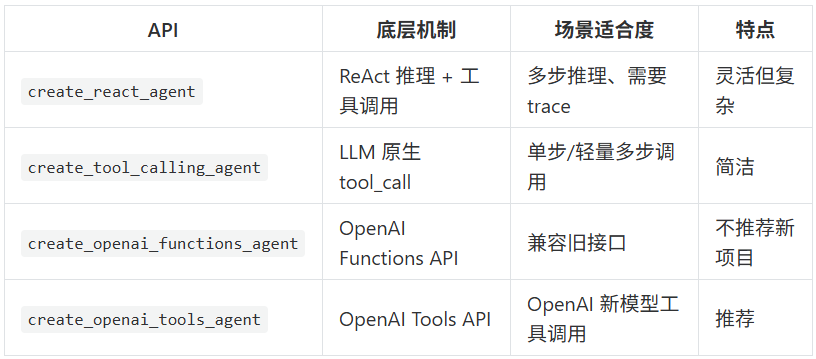

其中 React Agent（Reason + Act）是使用最多的一种经典的推理–执行型智能体模式：先思考（Reason），再选择动作（Act）。

### 3.2 接入自定义工具函数

LangGraph接入工具函数类别和LangChain一样有三类：LangChain内置的工具函数、自定义工具函数和使用MCP工具。使用@tool装饰器将自定义函数修饰为LangGraph的函数工具。

### 3.3 LangGraph ReACT图结构

LangGraph框架是通过Nodes（点）和Edges(边）的组合去创建复杂的循环工作流程，通过消息传递的方式串联所有节点形成一个通路。为了维持消息能够及时的更新并能够在节点中反复传递，则LangGraph构建了 State状态 的概念。每启动一个LangGraph构建流都会生成一个状态，图中的节点在处理时会传递和修改该状态。整个状态不仅仅是一组静态数据，更是根据每个节点的输出动态更新的，然后影响循环内的后续操作。

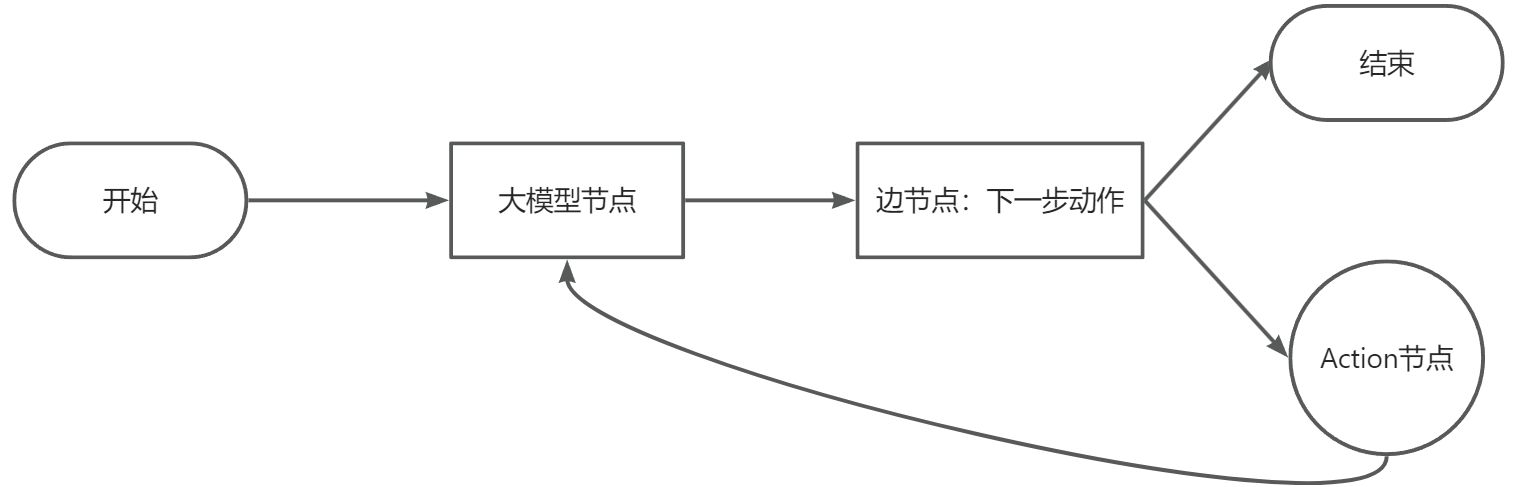

上图展示了ReACT图结构，ReACT是Reason（推理）和Act（行动）的缩写，它的工作流程是一个循环图：思考->行动->观察结果->再思考…->得出答案。正如上图所示，ReACT图具体流程如下:

1. 开始： 接收用户的输入
2. 调用模型： 将当前状态传递给大模型要求模型思考
3. 模型决策： 大模型会以特定格式返回一个响应，这个响应可能是：
    * 最终答案: 如果模型认为信息足够，就直接回答用户
    * 工具调用：如果模型认为需要更多信息，它会决定调用哪个工具
4. 执行工具：

    如果模型决定调用工具，图就会执行该工具，并获取工具返回的结果

5. 更新状态：

    将工具的执行结果添加到状态中

6. 循环：

    带着新的信息回到第2步，让模型再次思考

7. 结束：

    当模型返回最终答案时，循环结束，图运行完成将结果返回给用户。

## 四、实验内容

### 4.1 环境准备

给你一个整数数组 nums ，判断是否存在三元组 [nums[i], nums[j], nums[k]] 满足 i != j、i != k 且 j != k ，同时还满足 nums[i] + nums[j] + nums[k] == 0 。请你返回所有和为 0 且不重复的三元组。

注意：答案中不可以包含重复的三元组。

示例 1：

输入：nums = [-1,0,1,2,-1,-4]  
输出：[[-1,-1,2],[-1,0,1]]
解释：
nums[0] + nums[1] + nums[2] = (-1) + 0 + 1 = 0 。
nums[1] + nums[2] + nums[4] = 0 + 1 + (-1) = 0 。
nums[0] + nums[3] + nums[4] = (-1) + 2 + (-1) = 0 。
不同的三元组是 [-1,0,1] 和 [-1,-1,2] 。
注意，输出的顺序和三元组的顺序并不重要。
示例 2：

输入：nums = [0,1,1]
输出：[]
解释：唯一可能的三元组和不为 0 。
示例 3：

输入：nums = [0,0,0]
输出：[[0,0,0]]
解释：唯一可能的三元组和为 0 。

In [4]:
pip install langgraph

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
Note: you may need to restart the kernel to use updated packages.


### 4.2 自定义工具函数

In [5]:
import json
import os
import httpx
import dotenv
from loguru import logger
from pydantic import Field, BaseModel
from langchain_core.tools import tool

# 加载环境变量配置
dotenv.load_dotenv()

class WeatherQuery(BaseModel):
    """
    天气查询参数模型类，用于定义天气查询工具的输入参数结构。
    
    :param city: 城市名称，字符串类型，表示要查询天气的城市
    """
    city: str = Field(description="城市名称")

@tool(args_schema=WeatherQuery)
def get_weather(city):
    """
    查询指定城市的即时天气信息。

    :param city: 必要参数，字符串类型，表示要查询天气的城市名称。
                 注意：中国城市需使用其英文名称，如 "Beijing" 表示北京。
    :return: 返回 OpenWeather API 的响应结果，URL 为
             https://api.openweathermap.org/data/2.5/weather。
             响应内容为 JSON 格式的字符串，包含详细的天气数据。
    """
    # 构建请求 URL
    url = "https://api.openweathermap.org/data/2.5/weather"

    # 设置查询参数
    params = {
        "q": city, # 城市名称
        "appid": os.getenv("OPENWEATHER_API_KEY"),  # 从环境变量中读取 API Key
        "units": "metric",  # 使用摄氏度作为温度单位
        "lang": "zh_cn"     # 返回简体中文的天气描述
    }

    # 发送 GET 请求并获取响应
    response = httpx.get(url, params=params)

    # 将响应解析为 JSON 并序列化为字符串返回
    data = response.json()
    logger.info(f"查询天气结果：{json.dumps(data)}")
    return json.dumps(data)

print(get_weather.name)
print(get_weather.description)
print(get_weather.args)

get_weather
查询指定城市的即时天气信息。

:param city: 必要参数，字符串类型，表示要查询天气的城市名称。
             注意：中国城市需使用其英文名称，如 "Beijing" 表示北京。
:return: 返回 OpenWeather API 的响应结果，URL 为
         https://api.openweathermap.org/data/2.5/weather。
         响应内容为 JSON 格式的字符串，包含详细的天气数据。
{'city': {'description': '城市名称', 'title': 'City', 'type': 'string'}}


### 4.3 创建LangGraph智能体

### 4.4 添加多个工具函数
添加get_weather和write_file两个工具函数，分别用来查询天气和保存内容至文件。完整的项目代码如下:

In [7]:
import json
import os
import httpx
import dotenv
from loguru import logger
from pydantic import Field, BaseModel
from langchain_core.tools import tool

# 加载环境变量配置
dotenv.load_dotenv()

#规范工具参数
class WeatherQuery(BaseModel):
    """
    天气查询参数模型类，用于定义天气查询工具的输入参数结构。

    :param city: 城市名称，字符串类型，表示要查询天气的城市
    """
    city: str = Field(description="城市名称")


class WriteQuery(BaseModel):
    """
    写入查询模型类
    
    用于定义需要写入文档的内容结构，继承自BaseModel基类
    
    属性:
        content (str): 需要写入文档的具体内容，包含详细的描述信息
    """
    content: str = Field(description="需要写入文档的具体内容")



@tool(args_schema=WeatherQuery)
def get_weather(city):
    """
    查询指定城市的即时天气信息。

    :param city: 必要参数，字符串类型，表示要查询天气的城市名称。
                 注意：中国城市需使用其英文名称，如 "Beijing" 表示北京。
    :return: 返回 OpenWeather API 的响应结果，URL 为
             https://api.openweathermap.org/data/2.5/weather。
             响应内容为 JSON 格式的字符串，包含详细的天气数据。
    """
    # 构建请求 URL
    url = "https://api.openweathermap.org/data/2.5/weather"

    # 设置查询参数
    params = {
        "q": city,  # 城市名称
        "appid": os.getenv("OPENWEATHER_API_KEY"),  # 从环境变量中读取 API Key
        "units": "metric",  # 使用摄氏度作为温度单位
        "lang": "zh_cn"  # 返回简体中文的天气描述
    }

    # 发送 GET 请求并获取响应
    response = httpx.get(url, params=params)

    # 将响应解析为 JSON 并序列化为字符串返回
    data = response.json()
    logger.info(f"查询天气结果：{json.dumps(data)}")
    return json.dumps(data)


@tool(args_schema=WriteQuery)
def write_file(content):
    """
    将指定内容写入本地文件
    
    参数:
        content (str): 要写入文件的文本内容
    
    返回值:
        str: 表示写入操作成功完成的提示信息
    """
    # 将内容写入res.txt文件，使用utf-8编码确保中文字符正确保存
    with open('res.txt', 'w', encoding='utf-8') as f:
        f.write(content)
        logger.info(f"已成功写入本地文件，写入内容：{content}")
        return "已成功写入本地文件。"

### 4.5 工具并联调用

添加get_weather和write_file两个工具函数，分别用来查询天气和保存内容至文件。完整的项目代码如下:

In [8]:
from langchain_ollama import ChatOllama
from langgraph.prebuilt import create_react_agent
import os
import dotenv
from langchain.chat_models import init_chat_model
dotenv.load_dotenv(override=True)

# 初始化大语言模型
llm = init_chat_model(
    "deepseek-chat",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY")
)

# 定义工具列表，包含天气查询和结果写入工具
tools = [get_weather, write_file]

# 创建ReAct代理，结合语言模型和工具函数
agent = create_react_agent(model=llm, tools=tools)

# 调用代理处理用户查询，获取北京天气信息
response = agent.invoke({"messages": [{"role": "user", "content": "请问北京和上海今天谁更热？"}]})

# 输出完整响应结果和最终回答内容
print(response)
response["messages"][-1].pretty_print()

ModuleNotFoundError: No module named 'langchain_ollama'

### 4.6 工具串联调用

测试ReAct图智能体的工具并联调用，同时查询北京和杭州的天气。

In [ ]:
from langchain_ollama import ChatOllama
from langgraph.prebuilt import create_react_agent

# 定义工具列表，包含天气查询和结果写入工具
tools = [get_weather, write_file]

# 创建ReAct代理，结合语言模型和工具函数
agent = create_react_agent(model=llm, tools=tools)

# 调用代理处理用户查询，获取北京天气信息
response = agent.invoke({"messages": [{"role": "user", "content": "请问北京天气怎么样？然后把回答结果写入文件。"}]})
# 输出完整响应结果和最终回答内容
print(response)
response["messages"][-1].pretty_print()

## 五、实验总结

1. 理解了 LangGraph 的核心概念，掌握了图结构中节点、边、状态的协作关系
2. 通过预构建 API create_react_agent 快速创建了 ReACT 智能体
3. 使用 @tool 装饰器自定义了天气查询和文件写入工具函数
4. 通过工具并联调用，体验了大模型同时调用多个工具的能力
5. 通过工具串联调用，理解了多步骤任务的自动编排机制